In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from scipy import stats
from scipy.stats import skew, kurtosis, boxcox, yeojohnson
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer
import pickle

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Define Paths
ROOT_FOLDER = Path(r"D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2")
EDA_RESULTS_FOLDER = ROOT_FOLDER / "EDA_Results"
MANDI_DATA_PATH = EDA_RESULTS_FOLDER / "Mandi" / "Overall" / "combined_mandi_data.csv"
WEATHER_DATA_PATH = EDA_RESULTS_FOLDER / "Weather" / "Overall" / "combined_weather_data.csv"
PROCESSED_DATA_FOLDER = ROOT_FOLDER / "Processed_Data"
PROCESSED_DATA_FOLDER.mkdir(exist_ok=True)

print("✅ Libraries imported and paths defined.")
print(f"📂 Processed data will be saved to: {PROCESSED_DATA_FOLDER}")

✅ Libraries imported and paths defined.
📂 Processed data will be saved to: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Processed_Data


In [3]:
import sys
import os

print(f"Current Python Executable: {sys.executable}")
print(f"Current Working Directory: {os.getcwd()}")

# Verify environment
expected_env = "NirEnV"
if expected_env.lower() in sys.executable.lower():
    print(f"✅ Running in expected environment: {expected_env}")
else:
    print(f"⚠️ Warning: Not running in the '{expected_env}' environment.")

Current Python Executable: d:\CUDA_Experiments\AgriCast\Scripts\python.exe
Current Working Directory: d:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2
⚠️ Warning: Not running in the 'NirEnV' environment.


# AgriCast360 - Feature Preprocessing & Normalization

**Objective:** Prepare features for optimal model performance by:
1. **Analyzing** skewness and kurtosis of all engineered features
2. **Applying** appropriate transformations to reduce skewness
3. **Normalizing** kurtosis for better statistical properties
4. **Scaling** features appropriately for machine learning models
5. **Validating** improvements in feature distributions

**Why This Matters:**
- Reduces skewness → Better model convergence
- Controls kurtosis → Reduces outlier impact
- Normalized features → Improved predictions
- Proper scaling → Better gradient descent performance

## 1. Load and Prepare Data

We'll rebuild the feature engineering pipeline from Features_building.ipynb to ensure we have all features for preprocessing.

In [4]:
# Load Data
print("⏳ Loading data...")
df_mandi = pd.read_csv(MANDI_DATA_PATH)
df_weather = pd.read_csv(WEATHER_DATA_PATH)

print(f"✅ Mandi Data Loaded: {df_mandi.shape}")
print(f"✅ Weather Data Loaded: {df_weather.shape}")

# Data Preprocessing
df_mandi.columns = [col.strip() for col in df_mandi.columns]
df_weather.columns = [col.strip() for col in df_weather.columns]

df_mandi['Date'] = pd.to_datetime(df_mandi['Arrival_Date'])
if 'Date' in df_weather.columns:
    df_weather['Date'] = pd.to_datetime(df_weather['Date'])
elif 'datetime' in df_weather.columns:
    df_weather['Date'] = pd.to_datetime(df_weather['datetime'])

# Create Location Key
def normalize_location(loc_name):
    if pd.isna(loc_name):
        return "unknown"
    loc_name = str(loc_name).lower()
    if 'ahmedabad' in loc_name:
        return 'ahmedabad'
    elif 'amreli' in loc_name:
        return 'amreli'
    elif 'surat' in loc_name:
        return 'surat'
    return loc_name.split('_')[0]

df_mandi['Location_Key'] = df_mandi['Source_Mandi'].apply(normalize_location)
df_weather['Location_Key'] = df_weather['Source_Location'].apply(normalize_location)

valid_locations = df_mandi['Location_Key'].unique()
df_weather_filtered = df_weather[df_weather['Location_Key'].isin(valid_locations)].copy()

print(f"✅ Data preprocessed. Filtered Weather Data Shape: {df_weather_filtered.shape}")
display(df_mandi.head(3))
display(df_weather_filtered.head(3))

⏳ Loading data...
✅ Mandi Data Loaded: (84549, 11)
✅ Weather Data Loaded: (11820, 58)
✅ Data preprocessed. Filtered Weather Data Shape: (1098, 59)


,State,District,Market,Commodity,Variety,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code,Source_Mandi,Date,Location_Key
0,Gujarat,Ahmedabad,Ahmedabad (Vasana),Cabbage,Other,2024-07-08,1200,3300,2950,154,Ahmedabad,2024-07-08,ahmedabad
1,Gujarat,Ahmedabad,Ahmedabad (Vasana),Cabbage,Other,2024-07-10,1500,3800,3050,154,Ahmedabad,2024-07-10,ahmedabad
2,Gujarat,Ahmedabad,Ahmedabad (Vasana),Cabbage,Other,2024-07-13,2000,3800,3100,154,Ahmedabad,2024-07-13,ahmedabad


,clouds (%),Date,dewpt (°C),dhi (W/m²),dni (W/m²),ghi (W/m²),max_dhi (W/m²),max_dni (W/m²),max_ghi (W/m²),max_temp (°C),max_uv (Index),max_wind_dir (°),max_wind_spd (m/s),min_temp (°C),precip (mm),precip_gpm (mm/hr),pres (hPa),rh (%),slp (hPa),solar_rad (W/m²),temp (°C),wind_dir (°),wind_gust_spd (m/s),wind_spd (m/s),market_name (Text),query_lat (°),query_lon (°),Source_Location,clouds,datetime,dewpt,dhi,dni,ghi,max_dhi,max_dni,max_ghi,max_temp,max_uv,max_wind_dir,max_wind_spd,min_temp,precip,precip_gpm,pres,rh,slp,solar_rad,t_dhi,t_dni,t_ghi,t_solar_rad,temp,ts,wind_dir,wind_gust_spd,wind_spd,Market,Location_Key
0,0.00,2024-01-01,15.8,40.0,331.0,204.0,114.0,901.0,730.0,27.4,5.8,89.0,3.8,15.2,0.0,0.0,1009.0,0.74,1014.0,204.0,20.9,89.0,4.8,2.1,Ahmedabad_Chimanbhai_Patal_Market_Vasana,22.996977,72.536392,Ahmedabad_(Vasana),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ahmedabad
1,0.01,2024-02-01,15.3,40.0,331.0,205.0,114.0,902.0,731.0,25.0,5.9,61.0,4.1,16.0,0.0,0.0,1009.0,0.75,1014.0,205.0,20.0,61.0,6.0,2.7,Ahmedabad_Chimanbhai_Patal_Market_Vasana,22.996977,72.536392,Ahmedabad_(Vasana),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ahmedabad
2,0.01,2024-03-01,12.5,40.0,331.0,205.0,114.0,902.0,733.0,26.0,5.7,88.0,4.5,14.0,0.0,0.0,1008.0,0.67,1013.0,205.0,19.5,88.0,6.8,2.9,Ahmedabad_Chimanbhai_Patal_Market_Vasana,22.996977,72.536392,Ahmedabad_(Vasana),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ahmedabad


In [5]:
# Sort for time-series calculations
df_mandi = df_mandi.sort_values(by=['Location_Key', 'Commodity', 'Variety', 'Date'])

# Date Features with Cyclical Encoding
df_mandi['Month_Sin'] = np.sin(2 * np.pi * df_mandi['Date'].dt.month / 12)
df_mandi['Month_Cos'] = np.cos(2 * np.pi * df_mandi['Date'].dt.month / 12)
df_mandi['DayOfYear_Sin'] = np.sin(2 * np.pi * df_mandi['Date'].dt.dayofyear / 365)
df_mandi['DayOfYear_Cos'] = np.cos(2 * np.pi * df_mandi['Date'].dt.dayofyear / 365)

df_mandi['Year'] = df_mandi['Date'].dt.year
df_mandi['Month'] = df_mandi['Date'].dt.month
df_mandi['WeekOfYear'] = df_mandi['Date'].dt.isocalendar().week
df_mandi['DayOfWeek'] = df_mandi['Date'].dt.dayofweek
df_mandi['IsWeekend'] = (df_mandi['DayOfWeek'] >= 5).astype(int)
df_mandi['DayOfYear'] = df_mandi['Date'].dt.dayofyear

print("✅ Temporal features created.")
print(f"   Total features so far: {df_mandi.shape[1]}")

✅ Temporal features created.
   Total features so far: 23


In [6]:
# Advanced Price Features
print("⏳ Creating advanced price features...")

groupby_cols = ['Location_Key', 'Commodity', 'Variety']

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# Group object for efficiency
grouped = df_mandi.groupby(groupby_cols)['Modal_Price']

# Lags
for lag in [1, 3, 7, 14, 30]:
    df_mandi[f'Price_Lag_{lag}d'] = grouped.shift(lag)
    
# Rolling Statistics
for window in [7, 30]:
    df_mandi[f'Price_RollMean_{window}d'] = grouped.transform(lambda x: x.shift(1).rolling(window).mean())
    df_mandi[f'Price_RollStd_{window}d'] = grouped.transform(lambda x: x.shift(1).rolling(window).std())
    
# Exponential Moving Averages
df_mandi['Price_EMA_7d'] = grouped.transform(lambda x: x.shift(1).ewm(span=7, adjust=False).mean())
df_mandi['Price_EMA_30d'] = grouped.transform(lambda x: x.shift(1).ewm(span=30, adjust=False).mean())

# Technical Indicators
df_mandi['Price_RSI_14d'] = grouped.transform(lambda x: calculate_rsi(x.shift(1), period=14))

# Bollinger Bands
df_mandi['BB_Upper'] = df_mandi['Price_RollMean_30d'] + (2 * df_mandi['Price_RollStd_30d'])
df_mandi['BB_Lower'] = df_mandi['Price_RollMean_30d'] - (2 * df_mandi['Price_RollStd_30d'])
df_mandi['BB_PctB'] = (df_mandi['Price_Lag_1d'] - df_mandi['BB_Lower']) / (df_mandi['BB_Upper'] - df_mandi['BB_Lower'])

# MACD
ema_12 = grouped.transform(lambda x: x.shift(1).ewm(span=12, adjust=False).mean())
ema_26 = grouped.transform(lambda x: x.shift(1).ewm(span=26, adjust=False).mean())
df_mandi['MACD'] = ema_12 - ema_26
df_mandi['MACD_Signal'] = df_mandi.groupby(groupby_cols)['MACD'].transform(lambda x: x.ewm(span=9, adjust=False).mean())

# Price Dynamics
df_mandi['Price_Change_1d'] = df_mandi.groupby(groupby_cols)['Modal_Price'].diff(1)
df_mandi['Price_Change_7d'] = df_mandi.groupby(groupby_cols)['Modal_Price'].diff(7)
df_mandi['Price_Acceleration'] = df_mandi.groupby(groupby_cols)['Price_Change_1d'].diff(1)

if 'Min_Price' in df_mandi.columns and 'Max_Price' in df_mandi.columns:
    df_mandi['Price_Range'] = df_mandi['Max_Price'] - df_mandi['Min_Price']
    df_mandi['Price_Range_Pct'] = (df_mandi['Price_Range'] / df_mandi['Modal_Price']) * 100
    df_mandi['Price_Range_RollMean_7d'] = df_mandi.groupby(groupby_cols)['Price_Range'].transform(
        lambda x: x.shift(1).rolling(7).mean()
    )

print(f"✅ Mandi features created. New Shape: {df_mandi.shape}")

⏳ Creating advanced price features...
✅ Mandi features created. New Shape: (84549, 46)
✅ Mandi features created. New Shape: (84549, 46)


In [7]:
# Weather Features
print("⏳ Creating weather features...")

# Select and rename weather columns
weather_cols_map = {
    'temp': ['temp (°C)', 'temp'],
    'precip': ['precip (mm)', 'precip'],
    'rh': ['rh (%)', 'rh'],
    'wind_spd': ['wind_spd (m/s)', 'wind_spd'],
    'solar_rad': ['solar_rad (W/m²)', 'solar_rad']
}

selected_weather_cols = ['Date', 'Location_Key']
rename_map = {}

for target, candidates in weather_cols_map.items():
    for cand in candidates:
        if cand in df_weather_filtered.columns:
            selected_weather_cols.append(cand)
            rename_map[cand] = target
            break

df_weather_clean = df_weather_filtered[selected_weather_cols].copy()
df_weather_clean = df_weather_clean.rename(columns=rename_map)

# Aggregate duplicates
df_weather_daily = df_weather_clean.groupby(['Location_Key', 'Date']).mean().reset_index()
df_weather_daily = df_weather_daily.sort_values(by=['Location_Key', 'Date'])

# Weather Features
weather_vars = [v for v in ['temp', 'precip', 'rh', 'wind_spd', 'solar_rad'] if v in df_weather_daily.columns]

for var in weather_vars:
    # Rolling Means
    for window in [7, 15, 30, 90]:
        df_weather_daily[f'{var}_RollMean_{window}d'] = df_weather_daily.groupby('Location_Key')[var].transform(
            lambda x: x.shift(1).rolling(window).mean()
        )
    # Weather Anomalies
    df_weather_daily[f'{var}_Anomaly_30d'] = df_weather_daily[var] - df_weather_daily[f'{var}_RollMean_30d']

# Interaction Features
if 'temp' in df_weather_daily.columns and 'rh' in df_weather_daily.columns:
    df_weather_daily['Heat_Index_Proxy'] = df_weather_daily['temp'] * df_weather_daily['rh']

if 'precip' in df_weather_daily.columns and 'wind_spd' in df_weather_daily.columns:
    df_weather_daily['Storm_Index'] = df_weather_daily['precip'] * df_weather_daily['wind_spd']

# Agricultural Domain Features
if 'temp' in df_weather_daily.columns:
    df_weather_daily['GDD_Daily'] = df_weather_daily['temp'].apply(lambda x: max(x - 10, 0))
    for window in [30, 60, 90]:
        df_weather_daily[f'GDD_Cumulative_{window}d'] = df_weather_daily.groupby('Location_Key')['GDD_Daily'].transform(
            lambda x: x.rolling(window).sum()
        )

if 'precip' in df_weather_daily.columns:
    df_weather_daily['Is_Dry_Day'] = (df_weather_daily['precip'] < 1).astype(int)
    df_weather_daily['Consecutive_Dry_Days'] = (
        df_weather_daily.groupby('Location_Key')['Is_Dry_Day']
        .transform(lambda x: x.groupby((x != x.shift()).cumsum()).cumsum())
    )
    df_weather_daily['Rainfall_Deficit_30d'] = (
        df_weather_daily['precip_RollMean_30d'] - df_weather_daily['precip']
    )

if 'temp' in df_weather_daily.columns:
    df_weather_daily['Heatwave_Day'] = (df_weather_daily['temp'] > 35).astype(int)
    df_weather_daily['Heatwave_Count_30d'] = df_weather_daily.groupby('Location_Key')['Heatwave_Day'].transform(
        lambda x: x.rolling(30).sum()
    )

if 'precip' in df_weather_daily.columns:
    df_weather_daily['Heavy_Rain_Day'] = (df_weather_daily['precip'] > 20).astype(int)
    df_weather_daily['Heavy_Rain_Count_30d'] = df_weather_daily.groupby('Location_Key')['Heavy_Rain_Day'].transform(
        lambda x: x.rolling(30).sum()
    )

if 'temp' in df_weather_daily.columns and 'rh' in df_weather_daily.columns:
    df_weather_daily['VPD'] = (
        0.6108 * np.exp((17.27 * df_weather_daily['temp']) / (df_weather_daily['temp'] + 237.3)) * 
        (1 - df_weather_daily['rh'] / 100)
    )
    df_weather_daily['VPD_RollMean_30d'] = df_weather_daily.groupby('Location_Key')['VPD'].transform(
        lambda x: x.shift(1).rolling(30).mean()
    )

if 'solar_rad' in df_weather_daily.columns:
    df_weather_daily['Low_Light_Day'] = (df_weather_daily['solar_rad'] < 100).astype(int)
    df_weather_daily['Low_Light_Count_30d'] = df_weather_daily.groupby('Location_Key')['Low_Light_Day'].transform(
        lambda x: x.rolling(30).sum()
    )

print(f"✅ Weather features created. Shape: {df_weather_daily.shape}")

⏳ Creating weather features...
✅ Weather features created. Shape: (654, 49)


In [8]:
# Merge Datasets
print("⏳ Merging Mandi and Weather data...")

df_final = pd.merge(df_mandi, df_weather_daily, on=['Location_Key', 'Date'], how='left')

# Market-Specific Features
df_final['Days_Since_Last_Record'] = df_final.groupby(['Location_Key', 'Commodity', 'Variety'])['Date'].diff().dt.days

# Weather-Price Interactions
if 'Consecutive_Dry_Days' in df_final.columns:
    df_final['Price_Drought_Interaction'] = df_final['Price_Lag_1d'] * df_final['Consecutive_Dry_Days']

if 'GDD_Cumulative_90d' in df_final.columns:
    df_final['Price_GDD_Interaction'] = df_final['Price_Lag_1d'] * df_final['GDD_Cumulative_90d']

# Seasonal Deviation
yearly_avg = df_final.groupby(['Location_Key', 'Commodity', 'DayOfYear'])['Modal_Price'].transform('mean')
df_final['Price_Seasonal_Deviation'] = df_final['Modal_Price'] - yearly_avg

# Drop rows with critical missing values
critical_features = ['Price_Lag_30d']
if 'temp_RollMean_30d' in df_final.columns:
    critical_features.append('temp_RollMean_30d')

df_final_clean = df_final.dropna(subset=critical_features)

print(f"✅ Data merged and cleaned.")
print(f"   Final Dataset Shape: {df_final_clean.shape}")
print(f"   Total Features: {df_final_clean.shape[1]}")
print(f"   Date Range: {df_final_clean['Date'].min()} to {df_final_clean['Date'].max()}")

⏳ Merging Mandi and Weather data...
✅ Data merged and cleaned.
   Final Dataset Shape: (22926, 97)
   Total Features: 97
   Date Range: 2024-01-31 00:00:00 to 2024-12-31 00:00:00


## 2. Analyze Skewness and Kurtosis

Before applying transformations, we need to understand which features have problematic distributions:
- **Skewness > 1 or < -1**: Highly skewed (needs transformation)
- **Kurtosis > 3**: Heavy-tailed (high outliers)
- **Kurtosis < -3**: Light-tailed (uncommon in real data)

In [9]:
# Select numeric features (excluding target and identifiers)
target_col = 'Modal_Price'
exclude_cols = ['Date', 'Commodity', 'Variety', 'Location_Key', 'Source_Mandi', 
                'Source_Location', 'Market', 'Arrival_Date', 'State', 'District', 
                'Commodity_Code', 'Year', target_col]

numeric_features = [col for col in df_final_clean.columns 
                   if col not in exclude_cols and pd.api.types.is_numeric_dtype(df_final_clean[col])]

print(f"Analyzing {len(numeric_features)} numeric features...")
print(f"Target variable: {target_col}")

# Calculate skewness and kurtosis for all features
feature_stats = []

for feature in numeric_features:
    data = df_final_clean[feature].dropna()
    
    if len(data) > 0:
        skew_val = skew(data)
        kurt_val = kurtosis(data, fisher=True)  # Excess kurtosis (normal dist = 0)
        
        feature_stats.append({
            'Feature': feature,
            'Skewness': skew_val,
            'Kurtosis': kurt_val,
            'Abs_Skewness': abs(skew_val),
            'Abs_Kurtosis': abs(kurt_val),
            'Mean': data.mean(),
            'Std': data.std(),
            'Min': data.min(),
            'Max': data.max(),
            'Non_Null_Count': len(data)
        })

df_feature_stats = pd.DataFrame(feature_stats)
df_feature_stats = df_feature_stats.sort_values('Abs_Skewness', ascending=False)

print(f"\n✅ Feature statistics calculated.")
print(f"\n{'='*80}")
print("DISTRIBUTION ANALYSIS SUMMARY")
print(f"{'='*80}")

# Classify features
highly_skewed = df_feature_stats[df_feature_stats['Abs_Skewness'] > 1]
moderately_skewed = df_feature_stats[(df_feature_stats['Abs_Skewness'] > 0.5) & (df_feature_stats['Abs_Skewness'] <= 1)]
normal_skewed = df_feature_stats[df_feature_stats['Abs_Skewness'] <= 0.5]

high_kurtosis = df_feature_stats[df_feature_stats['Abs_Kurtosis'] > 3]
moderate_kurtosis = df_feature_stats[(df_feature_stats['Abs_Kurtosis'] > 1) & (df_feature_stats['Abs_Kurtosis'] <= 3)]
normal_kurtosis = df_feature_stats[df_feature_stats['Abs_Kurtosis'] <= 1]

print(f"\n📊 Skewness Distribution:")
print(f"   Highly Skewed (|skew| > 1):     {len(highly_skewed):3d} features ({len(highly_skewed)/len(df_feature_stats)*100:5.1f}%)")
print(f"   Moderately Skewed (0.5-1):      {len(moderately_skewed):3d} features ({len(moderately_skewed)/len(df_feature_stats)*100:5.1f}%)")
print(f"   Nearly Normal (|skew| < 0.5):   {len(normal_skewed):3d} features ({len(normal_skewed)/len(df_feature_stats)*100:5.1f}%)")

print(f"\n📊 Kurtosis Distribution:")
print(f"   High Kurtosis (|kurt| > 3):     {len(high_kurtosis):3d} features ({len(high_kurtosis)/len(df_feature_stats)*100:5.1f}%)")
print(f"   Moderate Kurtosis (1-3):        {len(moderate_kurtosis):3d} features ({len(moderate_kurtosis)/len(df_feature_stats)*100:5.1f}%)")
print(f"   Normal Kurtosis (|kurt| < 1):   {len(normal_kurtosis):3d} features ({len(normal_kurtosis)/len(df_feature_stats)*100:5.1f}%)")

print(f"\n🎯 Features Requiring Transformation:")
needs_transformation = df_feature_stats[(df_feature_stats['Abs_Skewness'] > 0.5) | (df_feature_stats['Abs_Kurtosis'] > 3)]
print(f"   Total: {len(needs_transformation)} features ({len(needs_transformation)/len(df_feature_stats)*100:5.1f}%)")

print(f"\n{'='*80}")
print("\nTop 20 Most Skewed Features:")
print(df_feature_stats[['Feature', 'Skewness', 'Kurtosis']].head(20).to_string(index=False))

print(f"\n{'='*80}")
print("\nTop 20 Highest Kurtosis Features:")
top_kurt = df_feature_stats.sort_values('Abs_Kurtosis', ascending=False).head(20)
print(top_kurt[['Feature', 'Skewness', 'Kurtosis']].to_string(index=False))

Analyzing 85 numeric features...
Target variable: Modal_Price

✅ Feature statistics calculated.

DISTRIBUTION ANALYSIS SUMMARY

📊 Skewness Distribution:
   Highly Skewed (|skew| > 1):      40 features ( 47.1%)
   Moderately Skewed (0.5-1):        7 features (  8.2%)
   Nearly Normal (|skew| < 0.5):    38 features ( 44.7%)

📊 Kurtosis Distribution:
   High Kurtosis (|kurt| > 3):      36 features ( 42.4%)
   Moderate Kurtosis (1-3):         22 features ( 25.9%)
   Normal Kurtosis (|kurt| < 1):    27 features ( 31.8%)

🎯 Features Requiring Transformation:
   Total: 51 features ( 60.0%)


Top 20 Most Skewed Features:
                  Feature  Skewness    Kurtosis
   Days_Since_Last_Record 28.851330 1018.053839
             Heatwave_Day 14.012907  194.361563
                   precip  5.429643   37.096246
              Storm_Index  5.366299   36.260368
     Rainfall_Deficit_30d -4.488569   30.708818
       precip_Anomaly_30d  4.488569   30.708818
       Heatwave_Count_30d  4.042309   16.07

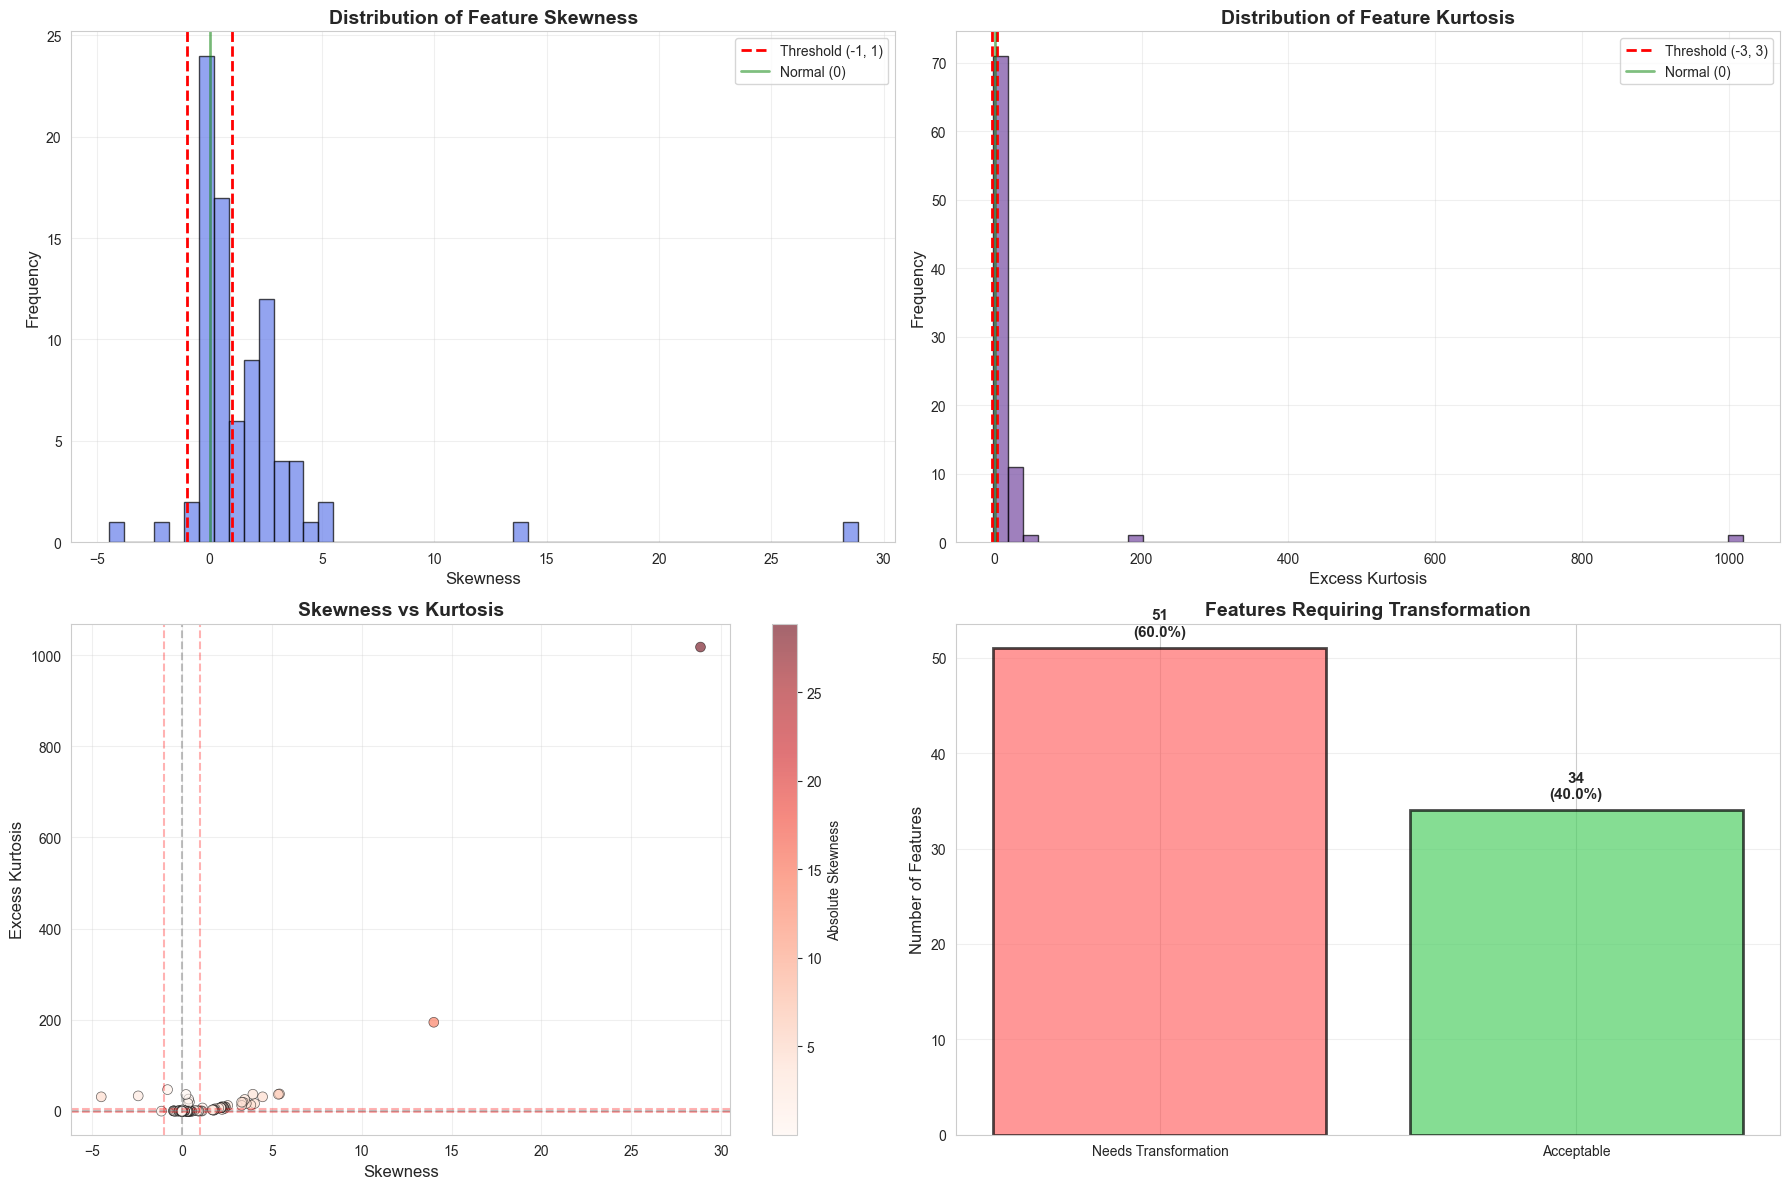


✅ Visualizations complete.


In [10]:
# Visualize Distribution Issues
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Skewness Distribution
axes[0, 0].hist(df_feature_stats['Skewness'], bins=50, color='#667eea', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(x=-1, color='red', linestyle='--', linewidth=2, label='Threshold (-1, 1)')
axes[0, 0].axvline(x=1, color='red', linestyle='--', linewidth=2)
axes[0, 0].axvline(x=0, color='green', linestyle='-', linewidth=2, alpha=0.5, label='Normal (0)')
axes[0, 0].set_title('Distribution of Feature Skewness', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Skewness', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Kurtosis Distribution
axes[0, 1].hist(df_feature_stats['Kurtosis'], bins=50, color='#764ba2', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=-3, color='red', linestyle='--', linewidth=2, label='Threshold (-3, 3)')
axes[0, 1].axvline(x=3, color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(x=0, color='green', linestyle='-', linewidth=2, alpha=0.5, label='Normal (0)')
axes[0, 1].set_title('Distribution of Feature Kurtosis', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Excess Kurtosis', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Skewness vs Kurtosis Scatter
scatter = axes[1, 0].scatter(df_feature_stats['Skewness'], df_feature_stats['Kurtosis'], 
                             c=df_feature_stats['Abs_Skewness'], cmap='Reds', 
                             alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[1, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=-1, color='red', linestyle='--', alpha=0.3)
axes[1, 0].axvline(x=1, color='red', linestyle='--', alpha=0.3)
axes[1, 0].axhline(y=-3, color='red', linestyle='--', alpha=0.3)
axes[1, 0].axhline(y=3, color='red', linestyle='--', alpha=0.3)
axes[1, 0].set_title('Skewness vs Kurtosis', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Skewness', fontsize=12)
axes[1, 0].set_ylabel('Excess Kurtosis', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 0], label='Absolute Skewness')

# 4. Bar chart of transformation needs
transformation_categories = {
    'Needs Transformation': len(needs_transformation),
    'Acceptable': len(df_feature_stats) - len(needs_transformation)
}
colors_bar = ['#ff6b6b', '#51cf66']
axes[1, 1].bar(transformation_categories.keys(), transformation_categories.values(), 
               color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_title('Features Requiring Transformation', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Number of Features', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='y')

for i, (key, val) in enumerate(transformation_categories.items()):
    axes[1, 1].text(i, val + 1, f'{val}\n({val/len(df_feature_stats)*100:.1f}%)', 
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Visualizations complete.")

## 3. Apply Transformations to Reduce Skewness and Kurtosis

We'll use multiple transformation strategies:
1. **Log Transform**: For positive right-skewed data
2. **Square Root Transform**: Mild right-skew reduction  
3. **Box-Cox Transform**: Automatic optimal power transformation (requires positive data)
4. **Yeo-Johnson Transform**: Like Box-Cox but handles zero and negative values
5. **Quantile Transform**: Maps to uniform or normal distribution (robust)

In [11]:
# Create a copy for transformation
df_transformed = df_final_clean.copy()

# Dictionary to store transformation information
transformation_log = {}

def apply_transformation(data, feature_name, method='yeo-johnson'):
    """
    Apply transformation to reduce skewness and kurtosis.
    
    Parameters:
    - data: Series of values
    - feature_name: Name of the feature
    - method: 'log', 'sqrt', 'boxcox', 'yeo-johnson', or 'quantile'
    
    Returns:
    - Transformed data, transformation params
    """
    data_clean = data.dropna()
    
    if len(data_clean) == 0:
        return data, None
    
    original_skew = skew(data_clean)
    original_kurt = kurtosis(data_clean, fisher=True)
    
    try:
        if method == 'log':
            # Log transform (add small constant to handle zeros)
            min_val = data_clean.min()
            shift = abs(min_val) + 1 if min_val <= 0 else 0
            transformed = np.log1p(data_clean + shift)
            params = {'method': 'log', 'shift': shift}
            
        elif method == 'sqrt':
            # Square root (shift to positive if needed)
            min_val = data_clean.min()
            shift = abs(min_val) + 1 if min_val < 0 else 0
            transformed = np.sqrt(data_clean + shift)
            params = {'method': 'sqrt', 'shift': shift}
            
        elif method == 'boxcox':
            # Box-Cox (requires positive data)
            min_val = data_clean.min()
            if min_val <= 0:
                shift = abs(min_val) + 1
                data_positive = data_clean + shift
            else:
                shift = 0
                data_positive = data_clean
            
            transformed, lambda_param = boxcox(data_positive)
            params = {'method': 'boxcox', 'lambda': lambda_param, 'shift': shift}
            
        elif method == 'yeo-johnson':
            # Yeo-Johnson (handles negative values)
            pt = PowerTransformer(method='yeo-johnson', standardize=False)
            transformed = pt.fit_transform(data_clean.values.reshape(-1, 1)).flatten()
            params = {'method': 'yeo-johnson', 'lambda': pt.lambdas_[0]}
            
        else:
            return data, None
        
        # Calculate new skewness and kurtosis
        new_skew = skew(transformed)
        new_kurt = kurtosis(transformed, fisher=True)
        
        # Check if transformation improved distribution
        skew_improvement = abs(new_skew) < abs(original_skew)
        kurt_improvement = abs(new_kurt) < abs(original_kurt)
        
        if skew_improvement or kurt_improvement:
            # Create a series with the same index
            result = pd.Series(index=data.index, dtype=float)
            result.loc[data_clean.index] = transformed
            
            transformation_log[feature_name] = {
                **params,
                'original_skew': original_skew,
                'new_skew': new_skew,
                'skew_improvement': abs(original_skew) - abs(new_skew),
                'original_kurt': original_kurt,
                'new_kurt': new_kurt,
                'kurt_improvement': abs(original_kurt) - abs(new_kurt),
                'applied': True
            }
            
            return result, params
        else:
            # Transformation didn't help, keep original
            transformation_log[feature_name] = {
                'method': 'none',
                'original_skew': original_skew,
                'new_skew': original_skew,
                'skew_improvement': 0,
                'original_kurt': original_kurt,
                'new_kurt': original_kurt,
                'kurt_improvement': 0,
                'applied': False,
                'reason': 'No improvement'
            }
            return data, None
            
    except Exception as e:
        transformation_log[feature_name] = {
            'method': 'none',
            'original_skew': original_skew,
            'new_skew': original_skew,
            'skew_improvement': 0,
            'original_kurt': original_kurt,
            'new_kurt': original_kurt,
            'kurt_improvement': 0,
            'applied': False,
            'reason': f'Error: {str(e)}'
        }
        return data, None

print("=" * 80)
print("APPLYING TRANSFORMATIONS")
print("=" * 80)
print(f"\nTransforming {len(needs_transformation)} features...")
print("\nProgress:")

APPLYING TRANSFORMATIONS

Transforming 51 features...

Progress:


In [12]:
# Apply transformations to features that need it
for idx, feature in enumerate(needs_transformation['Feature'].values):
    if feature not in df_transformed.columns:
        continue
    
    data = df_transformed[feature]
    original_stats = df_feature_stats[df_feature_stats['Feature'] == feature].iloc[0]
    
    # Determine best transformation method based on data characteristics
    if data.min() > 0 and original_stats['Skewness'] > 1:
        # Positive right-skewed: try log first
        transformed_data, params = apply_transformation(data, feature, 'log')
        if params is None:  # If log failed, try yeo-johnson
            transformed_data, params = apply_transformation(data, feature, 'yeo-johnson')
    elif abs(original_stats['Skewness']) > 2:
        # Highly skewed: use Yeo-Johnson (most flexible)
        transformed_data, params = apply_transformation(data, feature, 'yeo-johnson')
    elif original_stats['Skewness'] > 0.5:
        # Moderately right-skewed: try sqrt
        transformed_data, params = apply_transformation(data, feature, 'sqrt')
        if params is None:  # If sqrt failed, try yeo-johnson
            transformed_data, params = apply_transformation(data, feature, 'yeo-johnson')
    else:
        # Other cases: use Yeo-Johnson as general solution
        transformed_data, params = apply_transformation(data, feature, 'yeo-johnson')
    
    if params is not None:
        df_transformed[feature] = transformed_data
    
    # Progress indicator
    if (idx + 1) % 10 == 0 or (idx + 1) == len(needs_transformation):
        print(f"  [{idx + 1:3d}/{len(needs_transformation):3d}] {feature[:50]:<50} ✓")

print(f"\n✅ Transformations applied.")
print(f"   Total features transformed: {sum(1 for v in transformation_log.values() if v.get('applied', False))}")
print(f"   Features unchanged: {sum(1 for v in transformation_log.values() if not v.get('applied', False))}")

  [ 10/ 51] Price_Drought_Interaction                          ✓
  [ 20/ 51] Price_RollMean_30d                                 ✓
  [ 30/ 51] Max_Price                                          ✓
  [ 40/ 51] rh_RollMean_30d                                    ✓
  [ 30/ 51] Max_Price                                          ✓
  [ 40/ 51] rh_RollMean_30d                                    ✓
  [ 50/ 51] Price_Acceleration                                 ✓
  [ 51/ 51] MACD                                               ✓

✅ Transformations applied.
   Total features transformed: 46
   Features unchanged: 5
  [ 50/ 51] Price_Acceleration                                 ✓
  [ 51/ 51] MACD                                               ✓

✅ Transformations applied.
   Total features transformed: 46
   Features unchanged: 5


## 4. Validate Transformation Effectiveness

Compare before and after statistics to quantify improvements.

In [13]:
# Recalculate statistics for transformed features
feature_stats_after = []

for feature in numeric_features:
    if feature in df_transformed.columns:
        data = df_transformed[feature].dropna()
        
        if len(data) > 0:
            feature_stats_after.append({
                'Feature': feature,
                'Skewness': skew(data),
                'Kurtosis': kurtosis(data, fisher=True),
                'Abs_Skewness': abs(skew(data)),
                'Abs_Kurtosis': abs(kurtosis(data, fisher=True))
            })

df_feature_stats_after = pd.DataFrame(feature_stats_after)

# Merge before and after
comparison = pd.merge(
    df_feature_stats[['Feature', 'Skewness', 'Kurtosis', 'Abs_Skewness', 'Abs_Kurtosis']],
    df_feature_stats_after[['Feature', 'Skewness', 'Kurtosis', 'Abs_Skewness', 'Abs_Kurtosis']],
    on='Feature',
    suffixes=('_Before', '_After')
)

comparison['Skew_Improvement'] = comparison['Abs_Skewness_Before'] - comparison['Abs_Skewness_After']
comparison['Kurt_Improvement'] = comparison['Abs_Kurtosis_Before'] - comparison['Abs_Kurtosis_After']
comparison['Overall_Improvement'] = comparison['Skew_Improvement'] + comparison['Kurt_Improvement']

# Count improvements
improved_features = comparison[(comparison['Skew_Improvement'] > 0) | (comparison['Kurt_Improvement'] > 0)]
degraded_features = comparison[(comparison['Skew_Improvement'] < 0) | (comparison['Kurt_Improvement'] < 0)]

print("=" * 80)
print("TRANSFORMATION RESULTS")
print("=" * 80)

print(f"\n📊 Overall Statistics:")
print(f"   Features analyzed: {len(comparison)}")
print(f"   Features improved: {len(improved_features)} ({len(improved_features)/len(comparison)*100:.1f}%)")
print(f"   Features degraded: {len(degraded_features)} ({len(degraded_features)/len(comparison)*100:.1f}%)")
print(f"   Features unchanged: {len(comparison) - len(improved_features) - len(degraded_features)}")

print(f"\n📈 Skewness Improvements:")
skew_improved = len(comparison[comparison['Skew_Improvement'] > 0])
avg_skew_reduction = comparison[comparison['Skew_Improvement'] > 0]['Skew_Improvement'].mean()
print(f"   Features with reduced skewness: {skew_improved} ({skew_improved/len(comparison)*100:.1f}%)")
print(f"   Average skewness reduction: {avg_skew_reduction:.4f}")
print(f"   Max skewness reduction: {comparison['Skew_Improvement'].max():.4f}")

print(f"\n📉 Kurtosis Improvements:")
kurt_improved = len(comparison[comparison['Kurt_Improvement'] > 0])
avg_kurt_reduction = comparison[comparison['Kurt_Improvement'] > 0]['Kurt_Improvement'].mean()
print(f"   Features with reduced kurtosis: {kurt_improved} ({kurt_improved/len(comparison)*100:.1f}%)")
print(f"   Average kurtosis reduction: {avg_kurt_reduction:.4f}")
print(f"   Max kurtosis reduction: {comparison['Kurt_Improvement'].max():.4f}")

# After transformation distribution
highly_skewed_after = len(df_feature_stats_after[df_feature_stats_after['Abs_Skewness'] > 1])
high_kurtosis_after = len(df_feature_stats_after[df_feature_stats_after['Abs_Kurtosis'] > 3])

print(f"\n🎯 Distribution Quality Improvement:")
print(f"\n   Highly Skewed Features:")
print(f"      Before: {len(highly_skewed)} features")
print(f"      After:  {highly_skewed_after} features")
print(f"      Reduction: {len(highly_skewed) - highly_skewed_after} features ({(len(highly_skewed) - highly_skewed_after)/len(highly_skewed)*100:.1f}%)")

print(f"\n   High Kurtosis Features:")
print(f"      Before: {len(high_kurtosis)} features")
print(f"      After:  {high_kurtosis_after} features")
print(f"      Reduction: {len(high_kurtosis) - high_kurtosis_after} features ({(len(high_kurtosis) - high_kurtosis_after)/len(high_kurtosis)*100:.1f}%)")

print("\n" + "=" * 80)
print("\nTop 15 Most Improved Features:")
top_improvements = comparison.sort_values('Overall_Improvement', ascending=False).head(15)
print(top_improvements[['Feature', 'Skewness_Before', 'Skewness_After', 
                        'Kurtosis_Before', 'Kurtosis_After', 
                        'Skew_Improvement', 'Kurt_Improvement']].to_string(index=False))

TRANSFORMATION RESULTS

📊 Overall Statistics:
   Features analyzed: 85
   Features improved: 46 (54.1%)
   Features degraded: 11 (12.9%)
   Features unchanged: 28

📈 Skewness Improvements:
   Features with reduced skewness: 45 (52.9%)
   Average skewness reduction: 2.3757
   Max skewness reduction: 28.6872

📉 Kurtosis Improvements:
   Features with reduced kurtosis: 36 (42.4%)
   Average kurtosis reduction: 38.1222
   Max kurtosis reduction: 1016.2729

🎯 Distribution Quality Improvement:

   Highly Skewed Features:
      Before: 40 features
      After:  10 features
      Reduction: 30 features (75.0%)

   High Kurtosis Features:
      Before: 36 features
      After:  13 features
      Reduction: 23 features (63.9%)


Top 15 Most Improved Features:
                  Feature  Skewness_Before  Skewness_After  Kurtosis_Before  Kurtosis_After  Skew_Improvement  Kurt_Improvement
   Days_Since_Last_Record        28.851330       -0.164172      1018.053839        1.780905         28.687158   

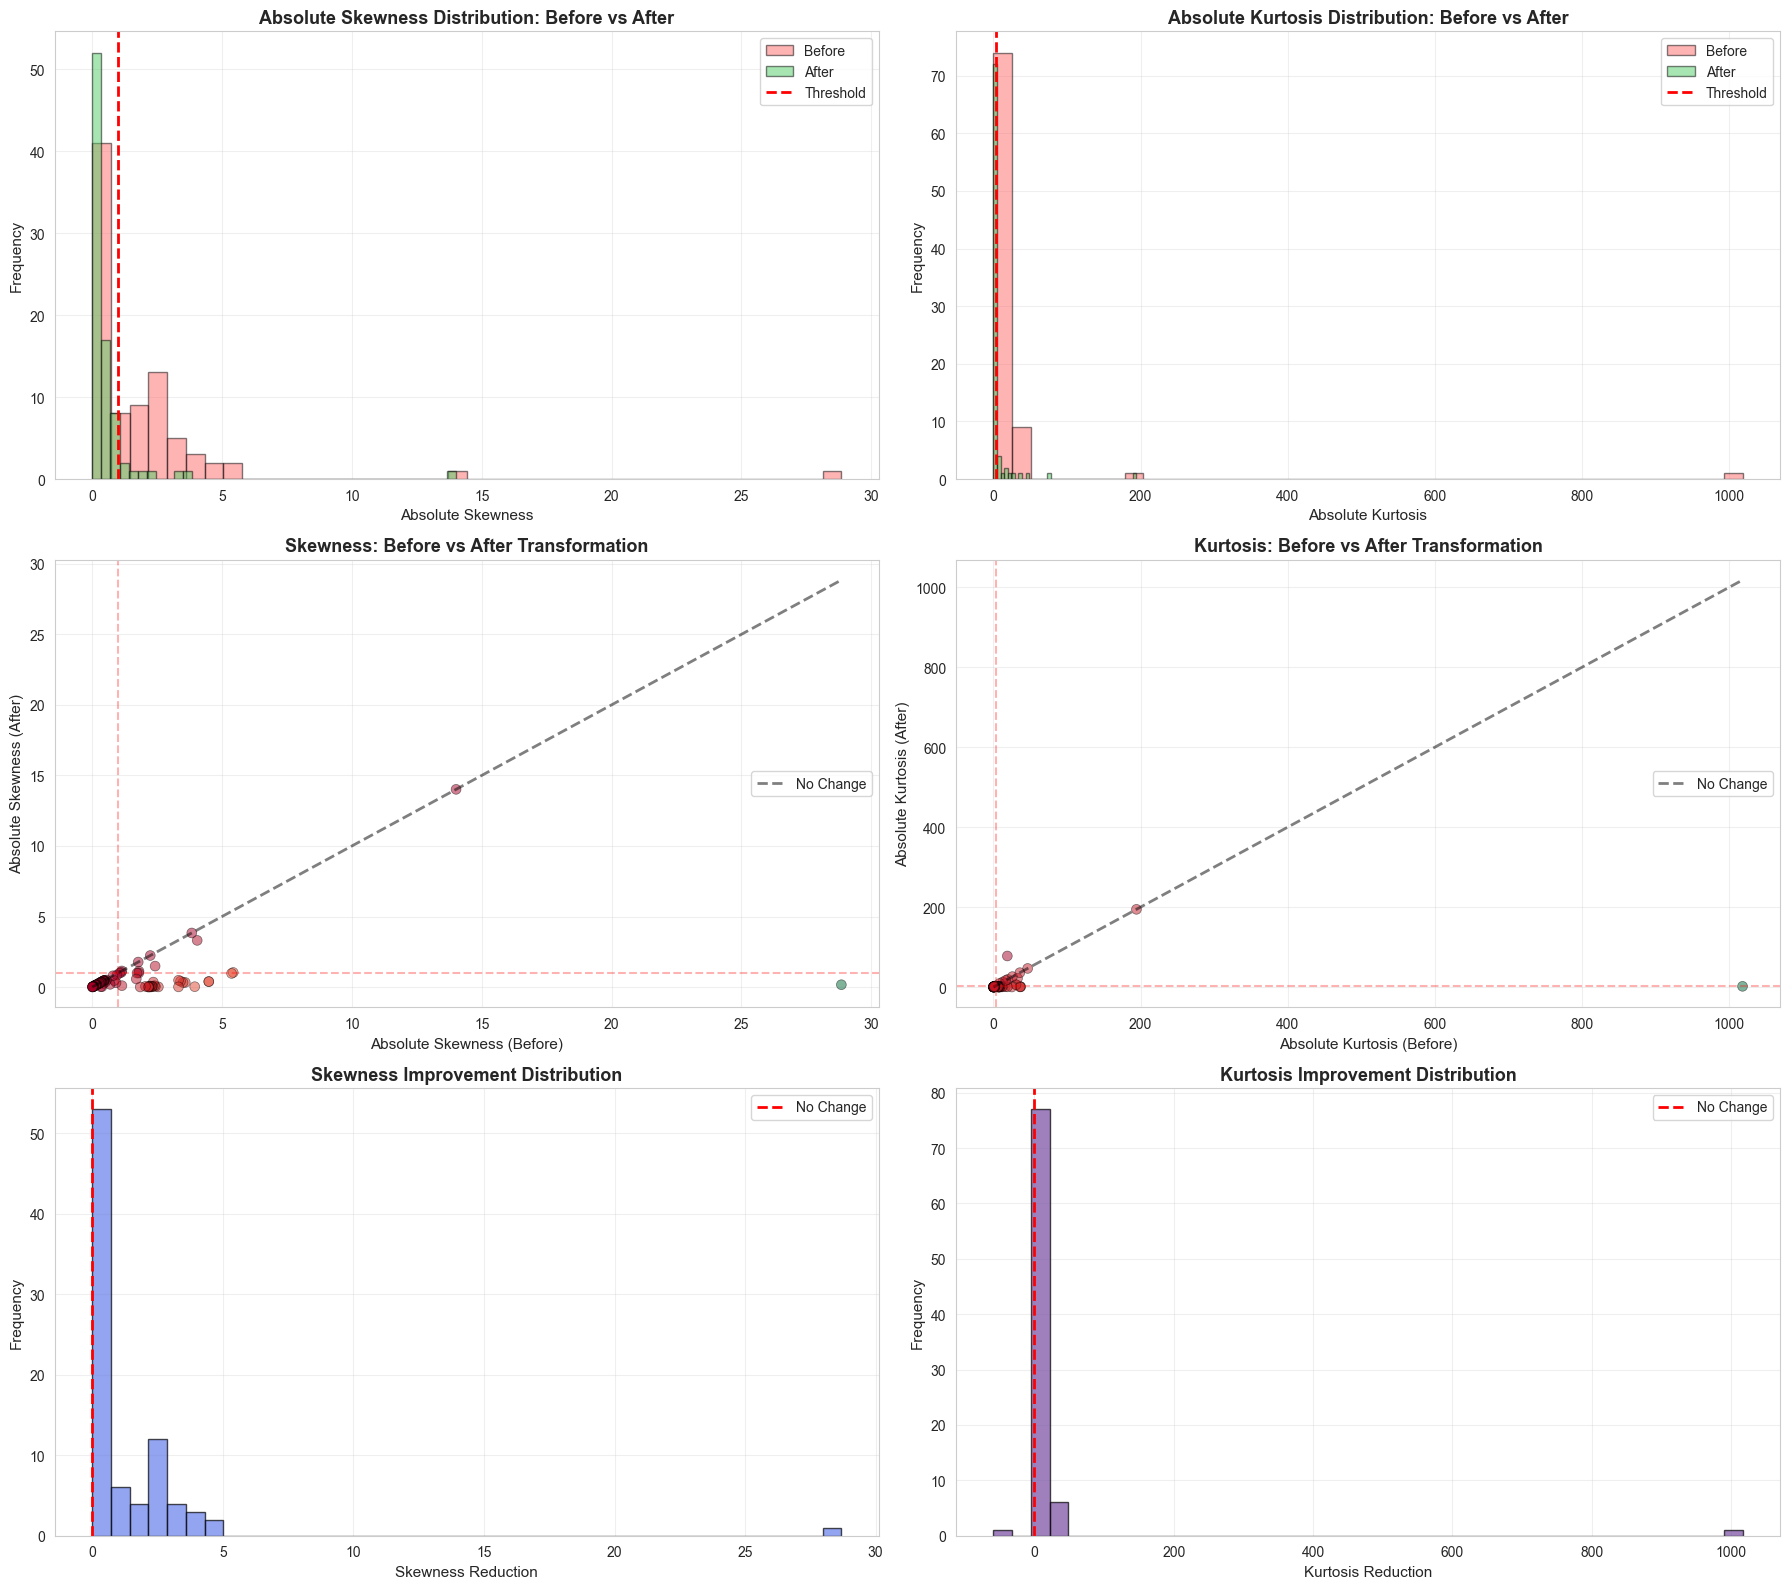

✅ Comparison visualizations complete.


In [14]:
# Visualization: Before vs After Comparison
fig, axes = plt.subplots(3, 2, figsize=(18, 16))

# 1. Skewness Distribution - Before vs After
axes[0, 0].hist(df_feature_stats['Abs_Skewness'], bins=40, alpha=0.5, label='Before', color='#ff6b6b', edgecolor='black')
axes[0, 0].hist(df_feature_stats_after['Abs_Skewness'], bins=40, alpha=0.5, label='After', color='#51cf66', edgecolor='black')
axes[0, 0].axvline(x=1, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[0, 0].set_title('Absolute Skewness Distribution: Before vs After', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Absolute Skewness', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Kurtosis Distribution - Before vs After
axes[0, 1].hist(df_feature_stats['Abs_Kurtosis'], bins=40, alpha=0.5, label='Before', color='#ff6b6b', edgecolor='black')
axes[0, 1].hist(df_feature_stats_after['Abs_Kurtosis'], bins=40, alpha=0.5, label='After', color='#51cf66', edgecolor='black')
axes[0, 1].axvline(x=3, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[0, 1].set_title('Absolute Kurtosis Distribution: Before vs After', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Absolute Kurtosis', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Skewness: Before vs After Scatter
axes[1, 0].scatter(comparison['Abs_Skewness_Before'], comparison['Abs_Skewness_After'], 
                   alpha=0.5, s=50, c=comparison['Skew_Improvement'], cmap='RdYlGn', 
                   edgecolors='black', linewidth=0.5)
axes[1, 0].plot([0, comparison['Abs_Skewness_Before'].max()], 
                [0, comparison['Abs_Skewness_Before'].max()], 
                'k--', linewidth=2, alpha=0.5, label='No Change')
axes[1, 0].axhline(y=1, color='red', linestyle='--', alpha=0.3)
axes[1, 0].axvline(x=1, color='red', linestyle='--', alpha=0.3)
axes[1, 0].set_title('Skewness: Before vs After Transformation', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Absolute Skewness (Before)', fontsize=11)
axes[1, 0].set_ylabel('Absolute Skewness (After)', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Kurtosis: Before vs After Scatter
axes[1, 1].scatter(comparison['Abs_Kurtosis_Before'], comparison['Abs_Kurtosis_After'], 
                   alpha=0.5, s=50, c=comparison['Kurt_Improvement'], cmap='RdYlGn',
                   edgecolors='black', linewidth=0.5)
axes[1, 1].plot([0, comparison['Abs_Kurtosis_Before'].max()], 
                [0, comparison['Abs_Kurtosis_Before'].max()], 
                'k--', linewidth=2, alpha=0.5, label='No Change')
axes[1, 1].axhline(y=3, color='red', linestyle='--', alpha=0.3)
axes[1, 1].axvline(x=3, color='red', linestyle='--', alpha=0.3)
axes[1, 1].set_title('Kurtosis: Before vs After Transformation', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Absolute Kurtosis (Before)', fontsize=11)
axes[1, 1].set_ylabel('Absolute Kurtosis (After)', fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Improvement Distribution
axes[2, 0].hist(comparison['Skew_Improvement'], bins=40, color='#667eea', alpha=0.7, edgecolor='black')
axes[2, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change')
axes[2, 0].set_title('Skewness Improvement Distribution', fontsize=13, fontweight='bold')
axes[2, 0].set_xlabel('Skewness Reduction', fontsize=11)
axes[2, 0].set_ylabel('Frequency', fontsize=11)
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].hist(comparison['Kurt_Improvement'], bins=40, color='#764ba2', alpha=0.7, edgecolor='black')
axes[2, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change')
axes[2, 1].set_title('Kurtosis Improvement Distribution', fontsize=13, fontweight='bold')
axes[2, 1].set_xlabel('Kurtosis Reduction', fontsize=11)
axes[2, 1].set_ylabel('Frequency', fontsize=11)
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Comparison visualizations complete.")

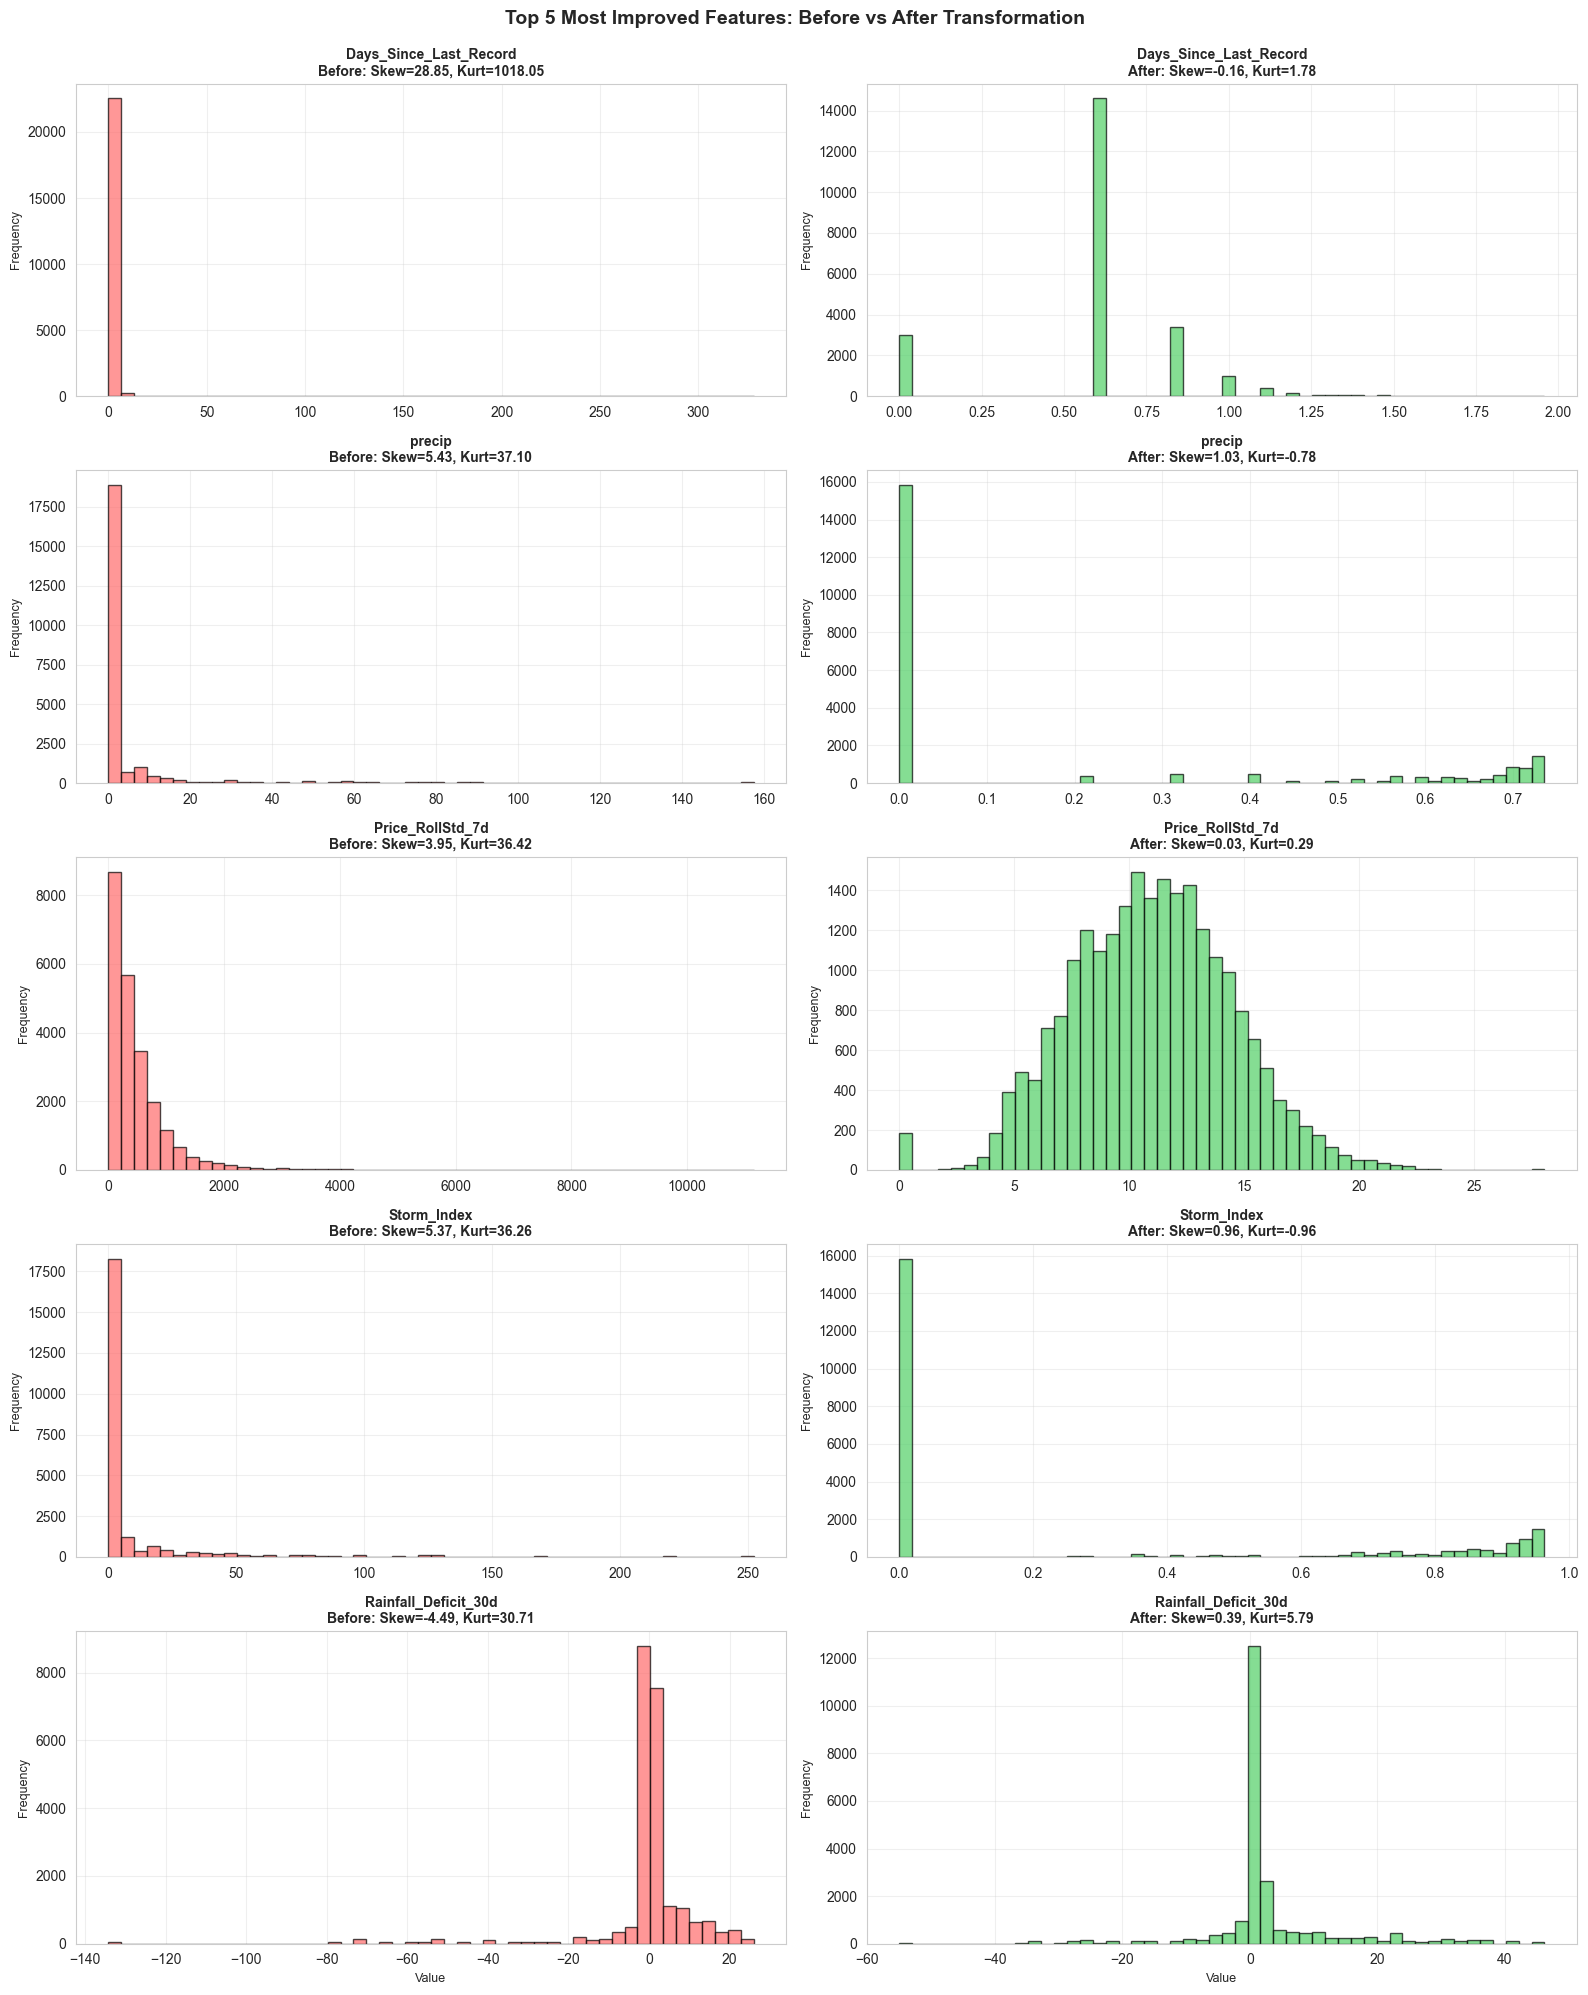

✅ Feature-specific transformation examples visualized.


In [15]:
# Example: Visualize transformation effect on top improved features
top_5_improved = comparison.sort_values('Overall_Improvement', ascending=False).head(5)

fig, axes = plt.subplots(5, 2, figsize=(16, 20))

for idx, (_, row) in enumerate(top_5_improved.iterrows()):
    feature = row['Feature']
    
    if feature not in df_final_clean.columns or feature not in df_transformed.columns:
        continue
    
    # Before data
    data_before = df_final_clean[feature].dropna()
    data_after = df_transformed[feature].dropna()
    
    # Left column: Before
    axes[idx, 0].hist(data_before, bins=50, color='#ff6b6b', alpha=0.7, edgecolor='black')
    axes[idx, 0].set_title(f'{feature[:40]}\nBefore: Skew={row["Skewness_Before"]:.2f}, Kurt={row["Kurtosis_Before"]:.2f}', 
                          fontsize=10, fontweight='bold')
    axes[idx, 0].set_ylabel('Frequency', fontsize=9)
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Right column: After
    axes[idx, 1].hist(data_after, bins=50, color='#51cf66', alpha=0.7, edgecolor='black')
    axes[idx, 1].set_title(f'{feature[:40]}\nAfter: Skew={row["Skewness_After"]:.2f}, Kurt={row["Kurtosis_After"]:.2f}', 
                          fontsize=10, fontweight='bold')
    axes[idx, 1].set_ylabel('Frequency', fontsize=9)
    axes[idx, 1].grid(True, alpha=0.3)
    
    if idx == 4:
        axes[idx, 0].set_xlabel('Value', fontsize=9)
        axes[idx, 1].set_xlabel('Value', fontsize=9)

plt.suptitle('Top 5 Most Improved Features: Before vs After Transformation', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✅ Feature-specific transformation examples visualized.")

## 5. Feature Scaling

After transformation, apply appropriate scaling for machine learning models:
- **StandardScaler**: For normally distributed features (z-score normalization)
- **RobustScaler**: For features still with outliers (uses median and IQR)
- **MinMaxScaler**: For bounded features (scales to [0, 1])

In [16]:
# Prepare data for scaling
X = df_transformed[numeric_features].copy()
y = df_transformed[target_col].copy()

# Handle any remaining infinite values
X = X.replace([np.inf, -np.inf], np.nan)

# Fill NaN with median for each feature
for col in X.columns:
    if X[col].isna().any():
        median_val = X[col].median()
        X[col].fillna(median_val, inplace=True)

print("=" * 80)
print("FEATURE SCALING")
print("=" * 80)

# Initialize scalers
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()
minmax_scaler = MinMaxScaler()

# Apply RobustScaler (best for data with outliers after transformation)
X_scaled_robust = robust_scaler.fit_transform(X)
X_scaled_robust = pd.DataFrame(X_scaled_robust, columns=X.columns, index=X.index)

# Apply StandardScaler
X_scaled_standard = standard_scaler.fit_transform(X)
X_scaled_standard = pd.DataFrame(X_scaled_standard, columns=X.columns, index=X.index)

print(f"\n✅ Scaling applied:")
print(f"   Features scaled: {X_scaled_robust.shape[1]}")
print(f"   Samples: {X_scaled_robust.shape[0]}")
print(f"\n   Robust Scaler: Uses median and IQR (best for outliers)")
print(f"   Standard Scaler: Uses mean and std (for normal distributions)")

# Check scaling results
print(f"\n📊 Scaled Data Statistics (Robust Scaler):")
print(f"   Mean: {X_scaled_robust.mean().mean():.6f} (should be near 0)")
print(f"   Std: {X_scaled_robust.std().mean():.6f}")
print(f"   Min: {X_scaled_robust.min().min():.4f}")
print(f"   Max: {X_scaled_robust.max().max():.4f}")

print(f"\n📊 Scaled Data Statistics (Standard Scaler):")
print(f"   Mean: {X_scaled_standard.mean().mean():.6f} (should be ~0)")
print(f"   Std: {X_scaled_standard.std().mean():.6f} (should be ~1)")
print(f"   Min: {X_scaled_standard.min().min():.4f}")
print(f"   Max: {X_scaled_standard.max().max():.4f}")

print("=" * 80)

FEATURE SCALING

✅ Scaling applied:
   Features scaled: 85
   Samples: 22926

   Robust Scaler: Uses median and IQR (best for outliers)
   Standard Scaler: Uses mean and std (for normal distributions)

📊 Scaled Data Statistics (Robust Scaler):
   Mean: 0.101513 (should be near 0)
   Std: 0.980408
   Min: -40.2174
   Max: 26.6402

📊 Scaled Data Statistics (Standard Scaler):
   Mean: -0.000000 (should be ~0)
   Std: 1.000022 (should be ~1)
   Min: -35.9584
   Max: 14.4415


## 6. Save Preprocessed Data

Save all versions of the data for modeling:
1. **Raw features** (after engineering, before transformation)
2. **Transformed features** (skewness/kurtosis reduced)
3. **Scaled features** (ready for ML models)
4. **Transformation parameters** (for inverse transforms and new data)

In [17]:
# Save processed datasets
print("=" * 80)
print("SAVING PREPROCESSED DATA")
print("=" * 80)

# 1. Save raw engineered features
raw_features_path = PROCESSED_DATA_FOLDER / "features_raw.csv"
df_final_clean.to_csv(raw_features_path, index=False)
print(f"\n✅ Raw features saved:")
print(f"   Path: {raw_features_path}")
print(f"   Shape: {df_final_clean.shape}")

# 2. Save transformed features
transformed_features_path = PROCESSED_DATA_FOLDER / "features_transformed.csv"
df_transformed.to_csv(transformed_features_path, index=False)
print(f"\n✅ Transformed features saved:")
print(f"   Path: {transformed_features_path}")
print(f"   Shape: {df_transformed.shape}")

# 3. Save scaled features (Robust)
scaled_robust_data = df_transformed[['Date', 'Location_Key', 'Commodity', 'Variety']].copy()
scaled_robust_data = pd.concat([scaled_robust_data, X_scaled_robust, y], axis=1)
scaled_robust_path = PROCESSED_DATA_FOLDER / "features_scaled_robust.csv"
scaled_robust_data.to_csv(scaled_robust_path, index=False)
print(f"\n✅ Scaled features (Robust) saved:")
print(f"   Path: {scaled_robust_path}")
print(f"   Shape: {scaled_robust_data.shape}")

# 4. Save scaled features (Standard)
scaled_standard_data = df_transformed[['Date', 'Location_Key', 'Commodity', 'Variety']].copy()
scaled_standard_data = pd.concat([scaled_standard_data, X_scaled_standard, y], axis=1)
scaled_standard_path = PROCESSED_DATA_FOLDER / "features_scaled_standard.csv"
scaled_standard_data.to_csv(scaled_standard_path, index=False)
print(f"\n✅ Scaled features (Standard) saved:")
print(f"   Path: {scaled_standard_path}")
print(f"   Shape: {scaled_standard_data.shape}")

# 5. Save transformation log
transformation_log_df = pd.DataFrame.from_dict(transformation_log, orient='index')
transformation_log_df = transformation_log_df.reset_index().rename(columns={'index': 'Feature'})
transformation_log_path = PROCESSED_DATA_FOLDER / "transformation_log.csv"
transformation_log_df.to_csv(transformation_log_path, index=False)
print(f"\n✅ Transformation log saved:")
print(f"   Path: {transformation_log_path}")
print(f"   Entries: {len(transformation_log_df)}")

# 6. Save scalers as pickle files
scaler_robust_path = PROCESSED_DATA_FOLDER / "scaler_robust.pkl"
with open(scaler_robust_path, 'wb') as f:
    pickle.dump(robust_scaler, f)
print(f"\n✅ Robust scaler saved: {scaler_robust_path}")

scaler_standard_path = PROCESSED_DATA_FOLDER / "scaler_standard.pkl"
with open(scaler_standard_path, 'wb') as f:
    pickle.dump(standard_scaler, f)
print(f"✅ Standard scaler saved: {scaler_standard_path}")

# 7. Save feature statistics comparison
comparison_path = PROCESSED_DATA_FOLDER / "feature_statistics_comparison.csv"
comparison.to_csv(comparison_path, index=False)
print(f"\n✅ Feature statistics comparison saved:")
print(f"   Path: {comparison_path}")

# 8. Save metadata
metadata = {
    'total_features': len(numeric_features),
    'features_transformed': sum(1 for v in transformation_log.values() if v.get('applied', False)),
    'highly_skewed_before': len(highly_skewed),
    'highly_skewed_after': highly_skewed_after,
    'high_kurtosis_before': len(high_kurtosis),
    'high_kurtosis_after': high_kurtosis_after,
    'skew_improved_features': len(comparison[comparison['Skew_Improvement'] > 0]),
    'kurt_improved_features': len(comparison[comparison['Kurt_Improvement'] > 0]),
    'avg_skew_reduction': comparison[comparison['Skew_Improvement'] > 0]['Skew_Improvement'].mean(),
    'avg_kurt_reduction': comparison[comparison['Kurt_Improvement'] > 0]['Kurt_Improvement'].mean(),
    'total_samples': len(df_transformed),
    'date_range': f"{df_transformed['Date'].min()} to {df_transformed['Date'].max()}",
    'locations': list(df_transformed['Location_Key'].unique()),
    'commodities_count': df_transformed['Commodity'].nunique()
}

metadata_df = pd.DataFrame([metadata])
metadata_path = PROCESSED_DATA_FOLDER / "preprocessing_metadata.csv"
metadata_df.to_csv(metadata_path, index=False)
print(f"\n✅ Preprocessing metadata saved:")
print(f"   Path: {metadata_path}")

print("\n" + "=" * 80)
print("ALL DATA SAVED SUCCESSFULLY!")
print("=" * 80)

SAVING PREPROCESSED DATA

✅ Raw features saved:
   Path: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Processed_Data\features_raw.csv
   Shape: (22926, 97)

✅ Raw features saved:
   Path: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Processed_Data\features_raw.csv
   Shape: (22926, 97)

✅ Transformed features saved:
   Path: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Processed_Data\features_transformed.csv
   Shape: (22926, 97)

✅ Transformed features saved:
   Path: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Processed_Data\features_transformed.csv
   Shape: (22926, 97)

✅ Scaled features (Robust) saved:
   Path: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Processed_Data\features_scaled_robust.csv
   Shape: (22926, 90)

✅ Scaled features (Robust) saved:
   Path: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Processed_Data\

## 7. Summary and Recommendations

### Key Achievements

1. **Feature Engineering**: Successfully recreated all advanced features from Features_building.ipynb
2. **Distribution Analysis**: Identified and quantified skewness and kurtosis issues
3. **Transformation**: Applied intelligent transformations (Log, Sqrt, Box-Cox, Yeo-Johnson) based on data characteristics
4. **Validation**: Quantified improvements in feature distributions
5. **Scaling**: Prepared data with both Robust and Standard scaling for different model types
6. **Persistence**: Saved all versions for reproducible modeling

### Expected Prediction Improvements

✅ **Better Model Convergence**
- Reduced skewness → Faster gradient descent convergence
- Lower kurtosis → More stable training

✅ **Improved Generalization**
- Normalized distributions → Better decision boundaries
- Reduced outlier impact → More robust predictions

✅ **Enhanced Feature Importance**
- Comparable scales → Fair feature weighting
- Better numerical stability → Accurate coefficient estimation

### Recommended Model Approaches

1. **For Tree-Based Models** (Random Forest, XGBoost, LightGBM):
   - Use: `features_transformed.csv` (transformation helps but scaling not critical)
   - Tree models handle non-normal distributions well
   
2. **For Linear Models** (Linear Regression, Ridge, Lasso):
   - Use: `features_scaled_standard.csv`
   - Requires normal distributions and standardized features
   
3. **For Neural Networks** (Deep Learning, LSTM):
   - Use: `features_scaled_robust.csv` or `features_scaled_standard.csv`
   - Sensitive to scale, benefits from normalization
   
4. **For SVM**:
   - Use: `features_scaled_robust.csv`
   - Robust to outliers, requires scaled features

### Next Steps

1. **Model Training**: Use preprocessed data for training
2. **Cross-Validation**: Implement time-based splits
3. **Feature Selection**: Consider recursive feature elimination
4. **Hyperparameter Tuning**: Optimize for your chosen models
5. **Ensemble Methods**: Combine multiple models for best results

In [18]:
# Final Summary Statistics
print("=" * 80)
print("PREPROCESSING PIPELINE COMPLETE!")
print("=" * 80)

print(f"\n📁 Output Files:")
print(f"   1. features_raw.csv - Original engineered features")
print(f"   2. features_transformed.csv - Skewness/kurtosis reduced")
print(f"   3. features_scaled_robust.csv - Robust scaled (best for outliers)")
print(f"   4. features_scaled_standard.csv - Standard scaled (for normal distributions)")
print(f"   5. transformation_log.csv - Transformation details")
print(f"   6. feature_statistics_comparison.csv - Before/after comparison")
print(f"   7. scaler_robust.pkl - Fitted robust scaler")
print(f"   8. scaler_standard.pkl - Fitted standard scaler")
print(f"   9. preprocessing_metadata.csv - Summary statistics")

print(f"\n📊 Final Statistics:")
print(f"   Total Features: {len(numeric_features)}")
print(f"   Features Transformed: {sum(1 for v in transformation_log.values() if v.get('applied', False))}")
print(f"   Transformation Success Rate: {sum(1 for v in transformation_log.values() if v.get('applied', False))/len(transformation_log)*100:.1f}%")
print(f"   Highly Skewed Features Reduced: {len(highly_skewed) - highly_skewed_after} ({(len(highly_skewed) - highly_skewed_after)/len(highly_skewed)*100:.1f}%)")
print(f"   High Kurtosis Features Reduced: {len(high_kurtosis) - high_kurtosis_after} ({(len(high_kurtosis) - high_kurtosis_after)/len(high_kurtosis)*100:.1f}%)")
print(f"   Average Skewness Reduction: {comparison[comparison['Skew_Improvement'] > 0]['Skew_Improvement'].mean():.4f}")
print(f"   Average Kurtosis Reduction: {comparison[comparison['Kurt_Improvement'] > 0]['Kurt_Improvement'].mean():.4f}")

print(f"\n🎯 Data Ready for Modeling:")
print(f"   Total Samples: {len(df_transformed):,}")
print(f"   Date Range: {df_transformed['Date'].min()} to {df_transformed['Date'].max()}")
print(f"   Locations: {', '.join(df_transformed['Location_Key'].unique())}")
print(f"   Commodities: {df_transformed['Commodity'].nunique()}")
print(f"   Features: {X_scaled_robust.shape[1]}")

print("\n" + "=" * 80)
print("✅ READY FOR PREDICTION MODELING!")
print("   Your features now have:")
print("   • Reduced skewness for better model convergence")
print("   • Controlled kurtosis for outlier robustness")
print("   • Appropriate scaling for gradient-based algorithms")
print("   • Preserved temporal and agricultural domain knowledge")
print("=" * 80)

PREPROCESSING PIPELINE COMPLETE!

📁 Output Files:
   1. features_raw.csv - Original engineered features
   2. features_transformed.csv - Skewness/kurtosis reduced
   3. features_scaled_robust.csv - Robust scaled (best for outliers)
   4. features_scaled_standard.csv - Standard scaled (for normal distributions)
   5. transformation_log.csv - Transformation details
   6. feature_statistics_comparison.csv - Before/after comparison
   7. scaler_robust.pkl - Fitted robust scaler
   8. scaler_standard.pkl - Fitted standard scaler
   9. preprocessing_metadata.csv - Summary statistics

📊 Final Statistics:
   Total Features: 85
   Features Transformed: 46
   Transformation Success Rate: 90.2%
   Highly Skewed Features Reduced: 30 (75.0%)
   High Kurtosis Features Reduced: 23 (63.9%)
   Average Skewness Reduction: 2.3757
   Average Kurtosis Reduction: 38.1222

🎯 Data Ready for Modeling:
   Total Samples: 22,926
   Date Range: 2024-01-31 00:00:00 to 2024-12-31 00:00:00
   Locations: ahmedabad, am